# 파노라마 합성 및 객체 검출

> **실험 목표**: SIFT, ORB, ALIKED의 객체 검출 정확도와 실행 시간을 비교하고, 기준 물체의 회전·크기·조명 변화에 대한 강건성을 평가합니다.

## 1. 실험 개요

연속 사진을 합성한 파노라마에서 기준 물체의 위치를 찾습니다. 각 방법은 특징점 추출·매칭, Lowe Ratio Test 또는 LightGlue 매칭, RANSAC 기반 호모그래피를 거쳐 검출 결과를 만듭니다.

## 2. 데이터 구성 및 확장 방식

- 기준 물체: `data/objects/target1.jpg`, `target2.jpg`, …
- 완성 파노라마: `results/panorama/SIFT/panorama1.jpg`, `ORB/panorama1.jpg`, `ALIKED/panorama1.jpg`
- 파일 번호가 같은 기준 물체와 방법별 파노라마를 자동 연결합니다.
- 각 방법은 자신이 합성한 파노라마에서 객체 검출까지 수행하므로 전체 파이프라인을 비교합니다.
- 현재는 1세트여도, 이후 5세트를 추가하면 코드 수정 없이 전체 케이스에 같은 실험을 적용합니다.

## 3. 평가 기준

- **검출 성공률**: 전체 케이스 중 객체 위치 검출에 성공한 비율
- **평균 탐색 시간**: 특징점 추출과 Coarse-to-Fine 타일 탐색에 걸린 시간
- **매칭 신뢰도**: RANSAC Inlier 수와 Inlier 비율
- **변형 조건**: 기준 상태, 회전 ±30°, 크기 75%·125%, 밝기 70%·130%


### 모듈별 역할

- `src/stitcher.py`: 연속 사진의 특징점 매칭, RANSAC, 호모그래피와 블렌딩으로 파노라마를 합성합니다.
- `src/object_finder.py`: 기준 물체 특징점을 재사용해 Coarse-to-Fine 타일 탐색을 수행하고, 최종 호모그래피를 파노라마 좌표의 Polygon으로 표시합니다.
- `src/main.py`: 합성·검출 모듈을 순서대로 실행하고 이미지·요약 JSON을 저장하는 파이프라인 진입점입니다.
- `src/project_paths.py`: 데이터와 결과물의 공통 경로, 객체 검출 결과 폴더 규칙을 관리합니다.


In [19]:
# ==========================================
# 라이브러리 및 프로젝트 모듈 Import
# ==========================================
import csv
import importlib
import logging
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

import src.experiment_runner as experiment_runner
importlib.reload(experiment_runner)

from src.logger import logger
from src.main import run_pipeline
from src.project_paths import (
    MATCHING_RESULT_DIR,
    OBJECT_DETECTION_RESULT_DIR,
    OBJECT_DIR,
    PANORAMA_IMAGE_DIR,
    PANORAMA_RESULT_DIR,
    project_path,
)
from src.result_cleanup import clear_results
from src.settings import OBJECT_DETECTION_CONFIG, PATH_CONFIG
from src.experiment_runner import (
    discover_test_cases,
    read_image_for_display,
    run_batch,
    save_experiment_csv,
    summarize_records,
)

# ==========================================
# Notebook 출력 및 로그 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)

for handler in logger.handlers:
    if isinstance(handler, logging.StreamHandler) and not isinstance(handler, logging.FileHandler):
        handler.setLevel(logging.ERROR)

# ==========================================
# 실험 공통 환경 설정
# - 이후 셀은 여기서 정의한 경로·방법·조건만 사용
# ==========================================
PANORAMA_MAX_SIDE = 2048
PANORAMA_METHODS = tuple(OBJECT_DETECTION_CONFIG['methods'])
METHODS = PANORAMA_METHODS

TILE_SIZE = tuple(OBJECT_DETECTION_CONFIG['tile_size'])
COARSE_STRIDE = tuple(OBJECT_DETECTION_CONFIG['coarse_stride'])
FINE_STRIDE = tuple(OBJECT_DETECTION_CONFIG['fine_stride'])
COARSE_TOP_K = OBJECT_DETECTION_CONFIG['coarse_top_k']
EARLY_STOP_INLIERS = OBJECT_DETECTION_CONFIG['early_stop_inliers']

RESULT_ROOT = OBJECT_DETECTION_RESULT_DIR / 'batch'
MATCHING_ROOT = MATCHING_RESULT_DIR
METRICS_DIR = OBJECT_DETECTION_RESULT_DIR / 'metrics'

CONDITIONS = [
    {'name': 'baseline', 'rotation_deg': 0, 'scale_factor': 1.0, 'brightness_factor': 1.0, 'save_visuals': True},
    {'name': 'rotation_minus30', 'rotation_deg': -30, 'scale_factor': 1.0, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'rotation_plus30', 'rotation_deg': 30, 'scale_factor': 1.0, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'scale_075', 'rotation_deg': 0, 'scale_factor': 0.75, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'scale_125', 'rotation_deg': 0, 'scale_factor': 1.25, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'brightness_070', 'rotation_deg': 0, 'scale_factor': 1.0, 'brightness_factor': 0.70, 'save_visuals': False},
    {'name': 'brightness_130', 'rotation_deg': 0, 'scale_factor': 1.0, 'brightness_factor': 1.30, 'save_visuals': False},
]

CONDITION_LABELS = {
    'baseline': '기본',
    'rotation_minus30': '회전 -30°',
    'rotation_plus30': '회전 +30°',
    'scale_075': '크기 75%',
    'scale_125': '크기 125%',
    'brightness_070': '조명 70%',
    'brightness_130': '조명 130%',
}

# ==========================================
# 이전 결과물 정리
# - True로 바꾼 뒤 실행하면 results/의 생성 파일을 삭제
# - .gitkeep, opencv.log와 폴더 구조는 유지
# ==========================================
DELETE_PREVIOUS_RESULTS = False
result_paths = clear_results(dry_run=not DELETE_PREVIOUS_RESULTS)

if DELETE_PREVIOUS_RESULTS:
    print(f'삭제 완료: {len(result_paths)}개 파일')
else:
    print(f'삭제 예정 파일: {len(result_paths)}개')
    print('삭제하려면 DELETE_PREVIOUS_RESULTS를 True로 변경한 뒤 다시 실행하세요.')


삭제 예정 파일: 402개
삭제하려면 DELETE_PREVIOUS_RESULTS를 True로 변경한 뒤 다시 실행하세요.


## 4. 파노라마 합성 실험

`src.main`은 선택한 방법으로 연속 사진을 합성한 뒤, 같은 방법으로 객체 검출까지 수행합니다. 이 절에서는 `main.py` 실행으로 저장된 방법별 `matching_stats.csv`를 읽어 파노라마 합성 단계의 매칭 품질을 비교합니다.

- **원시 매칭 수**: 특징점 매칭 직후의 후보 수
- **필터링 매칭 수**: Lowe Ratio Test 또는 LightGlue 후 남은 매칭 수
- **RANSAC Inlier 수·비율**: 기하학적으로 일관된 매칭의 수와 비율
- **파노라마 시각 비교**: 방법별 합성 이미지와 외곽선 결과 확인


In [20]:
# ==========================================
# main.py 기반 파노라마 합성 및 객체 검출 실행
# - 현재는 data/panorama의 연속 사진 1세트 사용
# - 이후 data/panorama_sets/set01, set02 ... 폴더 자동 탐색
# ==========================================
source_root = project_path(PATH_CONFIG['panorama_source_dir'])
source_sets = sorted(path for path in source_root.glob('*') if path.is_dir())
target_paths = sorted(OBJECT_DIR.glob('target*.jpg'))
target_by_id = {str(int(match.group())): path for path in target_paths if (match := re.search(r'\d+$', path.stem))}

if source_sets:
    pipeline_inputs = []
    for source_dir in source_sets:
        match = re.search(r'\d+$', source_dir.name)
        if match is None:
            raise ValueError(f'파노라마 세트 폴더명에 번호가 필요합니다: {source_dir.name}')

        case_id = str(int(match.group()))
        if case_id not in target_by_id:
            raise FileNotFoundError(f'target{case_id}.jpg 파일이 없습니다.')
        pipeline_inputs.append((case_id, source_dir, target_by_id[case_id]))
else:
    if len(target_paths) != 1:
        raise ValueError('현재는 panorama_sets 폴더가 없으므로 target 이미지가 하나여야 합니다.')
    fallback_match = re.search(r'\d+$', target_paths[0].stem)
    pipeline_inputs = [(str(int(fallback_match.group())), PANORAMA_IMAGE_DIR, target_paths[0])]

pipeline_summaries = []
for case_id, source_dir, reference_path in pipeline_inputs:
    for method in PANORAMA_METHODS:
        print(f'실행 중: set={source_dir.name}, method={method}')
        summary = run_pipeline(
            input_dir=source_dir,
            reference_path=reference_path,
            method=method,
            max_side=PANORAMA_MAX_SIDE,
            export_path=PANORAMA_RESULT_DIR / method / f'panorama{case_id}.jpg',
        )
        pipeline_summaries.append(summary)

print(f'전체 파이프라인 실행 완료: {len(pipeline_summaries)}회')


실행 중: set=panorama, method=SIFT
실행 중: set=panorama, method=ORB
실행 중: set=panorama, method=ALIKED
전체 파이프라인 실행 완료: 3회


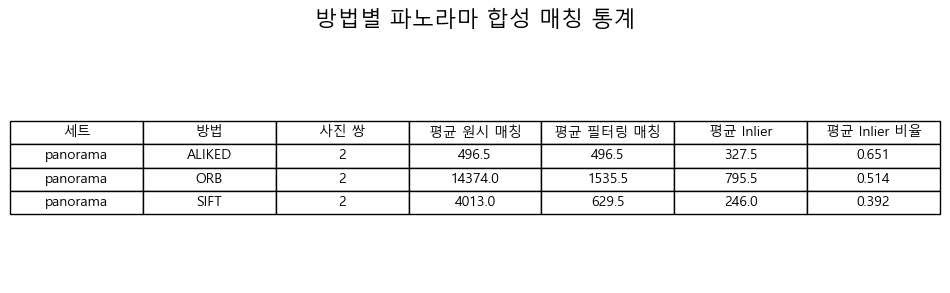

In [21]:
# ==========================================
# main.py 파노라마 합성 통계 수집 및 비교
# - results/panorama 아래의 방법별 matching_stats.csv 자동 탐색
# - 여러 세트가 추가되면 세트별 통계도 함께 집계
# ==========================================
panorama_summary_rows = []

for stats_path in sorted(PANORAMA_RESULT_DIR.rglob('matching_stats.csv')):
    method = stats_path.parent.name.upper()
    if method not in PANORAMA_METHODS:
        continue

    relative_parts = stats_path.relative_to(PANORAMA_RESULT_DIR).parts
    set_name = relative_parts[-3] if len(relative_parts) >= 3 else 'panorama'

    with stats_path.open(encoding='utf-8-sig', newline='') as file:
        pair_rows = list(csv.DictReader(file))

    if not pair_rows:
        continue

    panorama_candidates = [
        path for path in stats_path.parent.glob('panorama*.jpg')
        if path.stem != 'panorama_outline'
    ]

    panorama_summary_rows.append({
        'set': set_name,
        'method': method,
        'pair_count': len(pair_rows),
        'mean_raw_matches': np.mean([int(row['raw_match_count']) for row in pair_rows]),
        'mean_filtered_matches': np.mean([int(row['filtered_match_count']) for row in pair_rows]),
        'mean_inliers': np.mean([int(row['inlier_count']) for row in pair_rows]),
        'mean_inlier_ratio': np.mean([float(row['inlier_ratio']) for row in pair_rows]),
        'panorama_path': str(panorama_candidates[0]) if panorama_candidates else None,
    })

if not panorama_summary_rows:
    raise FileNotFoundError('results/panorama 아래에서 matching_stats.csv를 찾을 수 없습니다.')

panorama_table_rows = [
    [
        row['set'], row['method'], row['pair_count'],
        f"{row['mean_raw_matches']:.1f}",
        f"{row['mean_filtered_matches']:.1f}",
        f"{row['mean_inliers']:.1f}",
        f"{row['mean_inlier_ratio']:.3f}",
    ]
    for row in panorama_summary_rows
]

fig, axis = plt.subplots(figsize=(12, max(3, 0.5 * len(panorama_table_rows) + 1.5)))
axis.axis('off')
table = axis.table(
    cellText=panorama_table_rows,
    colLabels=['세트', '방법', '사진 쌍', '평균 원시 매칭', '평균 필터링 매칭', '평균 Inlier', '평균 Inlier 비율'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
axis.set_title('방법별 파노라마 합성 매칭 통계', fontsize=16, pad=18)
plt.show()


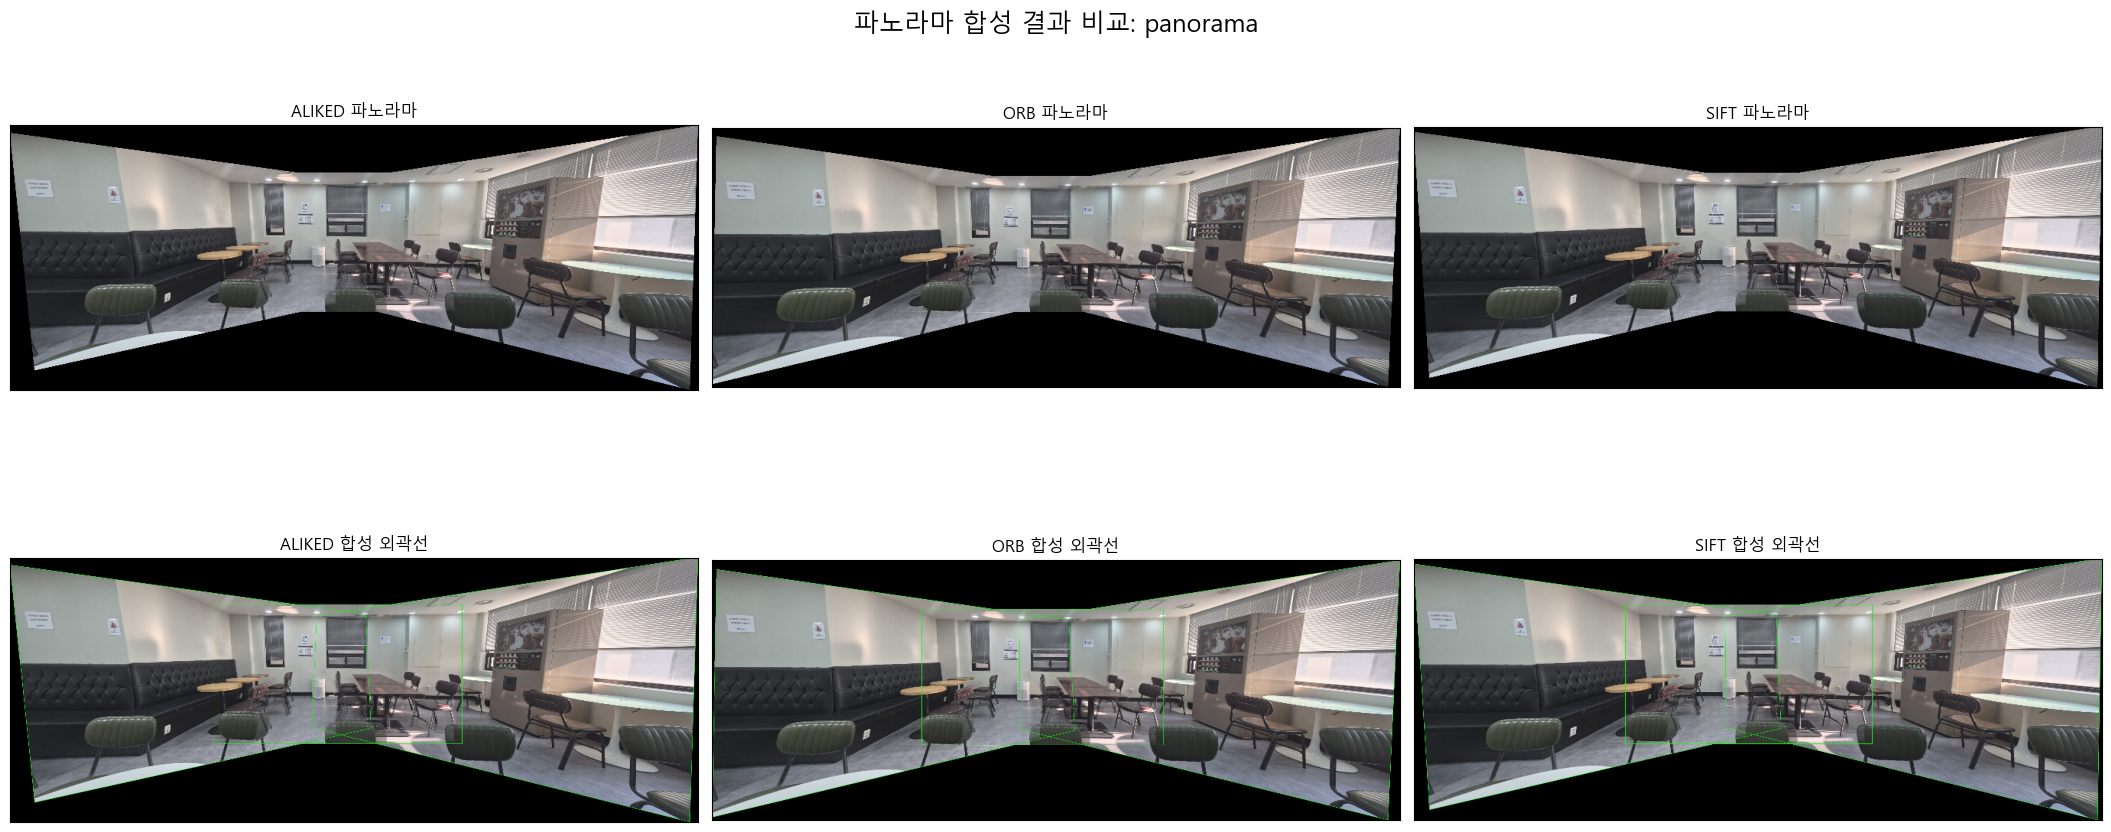

In [22]:
# ==========================================
# 방법별 파노라마 결과 시각 비교
# - 첫 번째 세트의 파노라마와 외곽선 이미지를 방법별로 표시
# ==========================================
visual_set = sorted({row['set'] for row in panorama_summary_rows})[0]
visual_rows = [row for row in panorama_summary_rows if row['set'] == visual_set]

fig, axes = plt.subplots(2, len(visual_rows), figsize=(7 * len(visual_rows), 9), constrained_layout=True)
axes = np.atleast_2d(axes)

for column, row in enumerate(visual_rows):
    panorama_path = Path(row['panorama_path'])
    outline_path = panorama_path.parent / 'panorama_outline.jpg'

    axes[0, column].imshow(read_image_for_display(panorama_path, max_width=900))
    axes[0, column].set_title(f"{row['method']} 파노라마", fontsize=12)

    if outline_path.is_file():
        axes[1, column].imshow(read_image_for_display(outline_path, max_width=900))
    else:
        axes[1, column].text(0.5, 0.5, '외곽선 결과가 없습니다.', ha='center', va='center')
    axes[1, column].set_title(f"{row['method']} 합성 외곽선", fontsize=12)

    for axis in axes[:, column]:
        axis.set_xticks([])
        axis.set_yticks([])

fig.suptitle(f'파노라마 합성 결과 비교: {visual_set}', fontsize=18)
plt.show()


## 5. 객체 검출 공통 설정과 실험 조건

타일 크기, 탐색 간격, 후보 수, 조기 종료 기준은 `config.json`의 객체 검출 설정을 그대로 사용합니다. 모든 방법에 동일한 조건을 적용해 비교의 공정성을 유지합니다. 기준 물체에는 아래 7개 변형 조건을 적용합니다.

In [23]:
# ==========================================
# ==========================================
# 실험 설정 확인
# - Import·환경 설정 셀의 공통 값을 사용
# ==========================================
print('방법:', ', '.join(METHODS))
print('타일:', TILE_SIZE, '| Coarse:', COARSE_STRIDE, '| Fine:', FINE_STRIDE)
print('변형 조건 수:', len(CONDITIONS))


방법: SIFT, ORB, ALIKED
타일: (512, 512) | Coarse: (512, 512) | Fine: (256, 256)
변형 조건 수: 7


## 6. 객체 검출 테스트 케이스 자동 탐색

`targetN.jpg`와 방법별 `panoramaN.jpg`의 번호가 같은 파일을 자동으로 연결합니다. 따라서 5개 세트가 준비되면 5개의 테스트 케이스가 만들어지고, 각 방법의 파노라마 합성 결과부터 객체 검출까지 일괄 실험합니다.

In [24]:
# ==========================================
# 테스트 데이터 자동 탐색
# - targetN.jpg와 panoramaN.jpg를 번호 기준으로 연결
# ==========================================
TEST_CASES = discover_test_cases(
    target_dir=OBJECT_DIR,
    panorama_result_dir=PANORAMA_RESULT_DIR,
    methods=METHODS,
)

print('자동 탐색된 테스트 세트 수: ' + str(len(TEST_CASES)))
print('총 실험 횟수: ' + str(len(TEST_CASES) * len(METHODS) * len(CONDITIONS)))

자동 탐색된 테스트 세트 수: 1
총 실험 횟수: 21


## 7. 일괄 객체 검출 실험

각 테스트 케이스와 변형 조건에 대해 SIFT, ORB, ALIKED를 순차 실행합니다. 기준 상태(`baseline`)는 검출 결과와 최종 타일 매칭 이미지를 저장하고, 모든 조건의 수치 결과는 CSV로 저장합니다.

In [25]:
# ==========================================
# 전체 방법·변형 조건 일괄 실험
# - 정확도: 정답 쌍에서의 검출 성공률
# - 속도: 특징점 추출부터 Tile Scan까지의 전체 실행 시간
# ==========================================
batch_records = run_batch(
    test_cases=TEST_CASES,
    methods=METHODS,
    conditions=CONDITIONS,
    tile_size=TILE_SIZE,
    coarse_stride=COARSE_STRIDE,
    fine_stride=FINE_STRIDE,
    coarse_top_k=COARSE_TOP_K,
    early_stop_inliers=EARLY_STOP_INLIERS,
    result_root=RESULT_ROOT,
    matching_root=MATCHING_ROOT,
)

summary_rows = summarize_records(batch_records)
csv_paths = save_experiment_csv(
    records=batch_records,
    summary=summary_rows,
    output_dir=METRICS_DIR,
)

print('실험 완료: ' + str(len(batch_records)) + '회')
print('원본 기록 CSV: ' + csv_paths['records'])
print('요약 비교표 CSV: ' + csv_paths['summary'])

실험 완료: 21회
원본 기록 CSV: D:\workspace\OpenCV\results\object_detection\metrics\experiment_records.csv
요약 비교표 CSV: D:\workspace\OpenCV\results\object_detection\metrics\method_condition_summary.csv


## 8. 객체 검출 정량적 결과 비교

아래 표는 방법·변형 조건별 성공률, 평균 탐색 시간, 평균 Inlier 비율을 보여 줍니다. 성공률은 검출 안정성, 평균 시간은 처리 속도, Inlier 비율은 매칭의 기하학적 신뢰도를 판단하는 지표입니다.

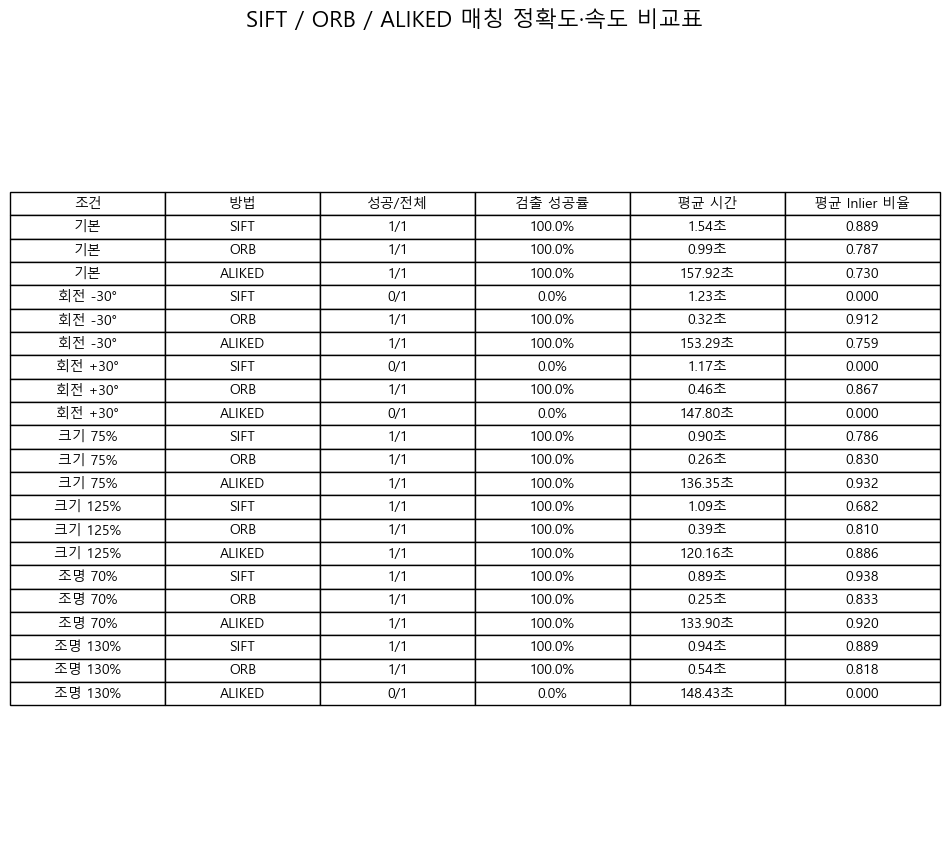

In [26]:
# ==========================================
# 방법별 매칭 정확도·속도 비교표 및 그래프
# - 정확도: Detection Success Rate
# - 속도: 평균 전체 실행 시간
# ==========================================
condition_names = [condition['name'] for condition in CONDITIONS]
summary_by_key = {(row['method'], row['condition']): row for row in summary_rows}

table_rows = []
for condition_name in condition_names:
    for method in METHODS:
        row = summary_by_key[(method, condition_name)]
        table_rows.append([
            CONDITION_LABELS[condition_name],
            method,
            str(row['detection_count']) + '/' + str(row['total_cases']),
            format(row['success_rate'] * 100, '.1f') + '%',
            format(row['mean_elapsed'], '.2f') + '초',
            format(row['mean_inlier_ratio'], '.3f'),
        ])

fig, axis = plt.subplots(figsize=(12, max(4, 0.42 * len(table_rows) + 1.5)))
axis.axis('off')
table = axis.table(
    cellText=table_rows,
    colLabels=['조건', '방법', '성공/전체', '검출 성공률', '평균 시간', '평균 Inlier 비율'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
axis.set_title('SIFT / ORB / ALIKED 매칭 정확도·속도 비교표', fontsize=16, pad=18)
plt.show()



### 8.1 조건별 성공률과 처리 시간

그래프를 통해 회전·크기·조명 변화가 각 방법에 미치는 영향을 비교합니다. 같은 조건에서 성공률이 높고 평균 시간이 짧을수록 실용적인 방법으로 평가할 수 있습니다.

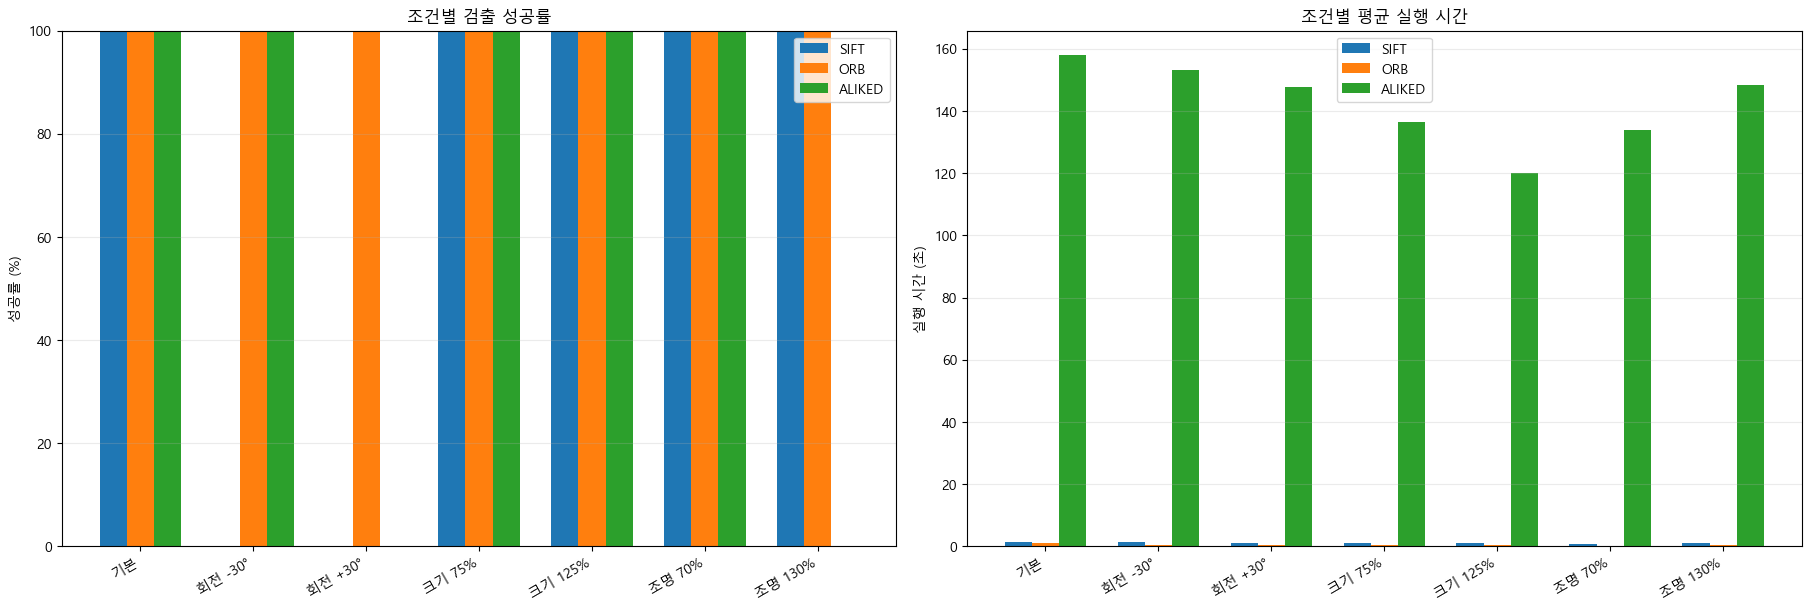

In [27]:
x_positions = np.arange(len(condition_names))
bar_width = 0.24
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

for index, method in enumerate(METHODS):
    success_rates = [summary_by_key[(method, name)]['success_rate'] * 100 for name in condition_names]
    elapsed_times = [summary_by_key[(method, name)]['mean_elapsed'] for name in condition_names]
    offset = (index - 1) * bar_width
    axes[0].bar(x_positions + offset, success_rates, bar_width, label=method)
    axes[1].bar(x_positions + offset, elapsed_times, bar_width, label=method)

labels = [CONDITION_LABELS[name] for name in condition_names]
axes[0].set_title('조건별 검출 성공률')
axes[0].set_ylabel('성공률 (%)')
axes[0].set_ylim(0, 100)
axes[1].set_title('조건별 평균 실행 시간')
axes[1].set_ylabel('실행 시간 (초)')

for axis in axes:
    axis.set_xticks(x_positions)
    axis.set_xticklabels(labels, rotation=30, ha='right')
    axis.legend()
    axis.grid(axis='y', alpha=0.25)

plt.show()

## 9. 객체 검출 정성적 결과 확인

위 행은 파노라마 전체에서 검출된 객체 Polygon, 아래 행은 최종 선택 타일의 특징점 매칭입니다. 수치 지표와 함께 Polygon 위치와 매칭선의 분포를 확인해 오검출 여부를 검토합니다.

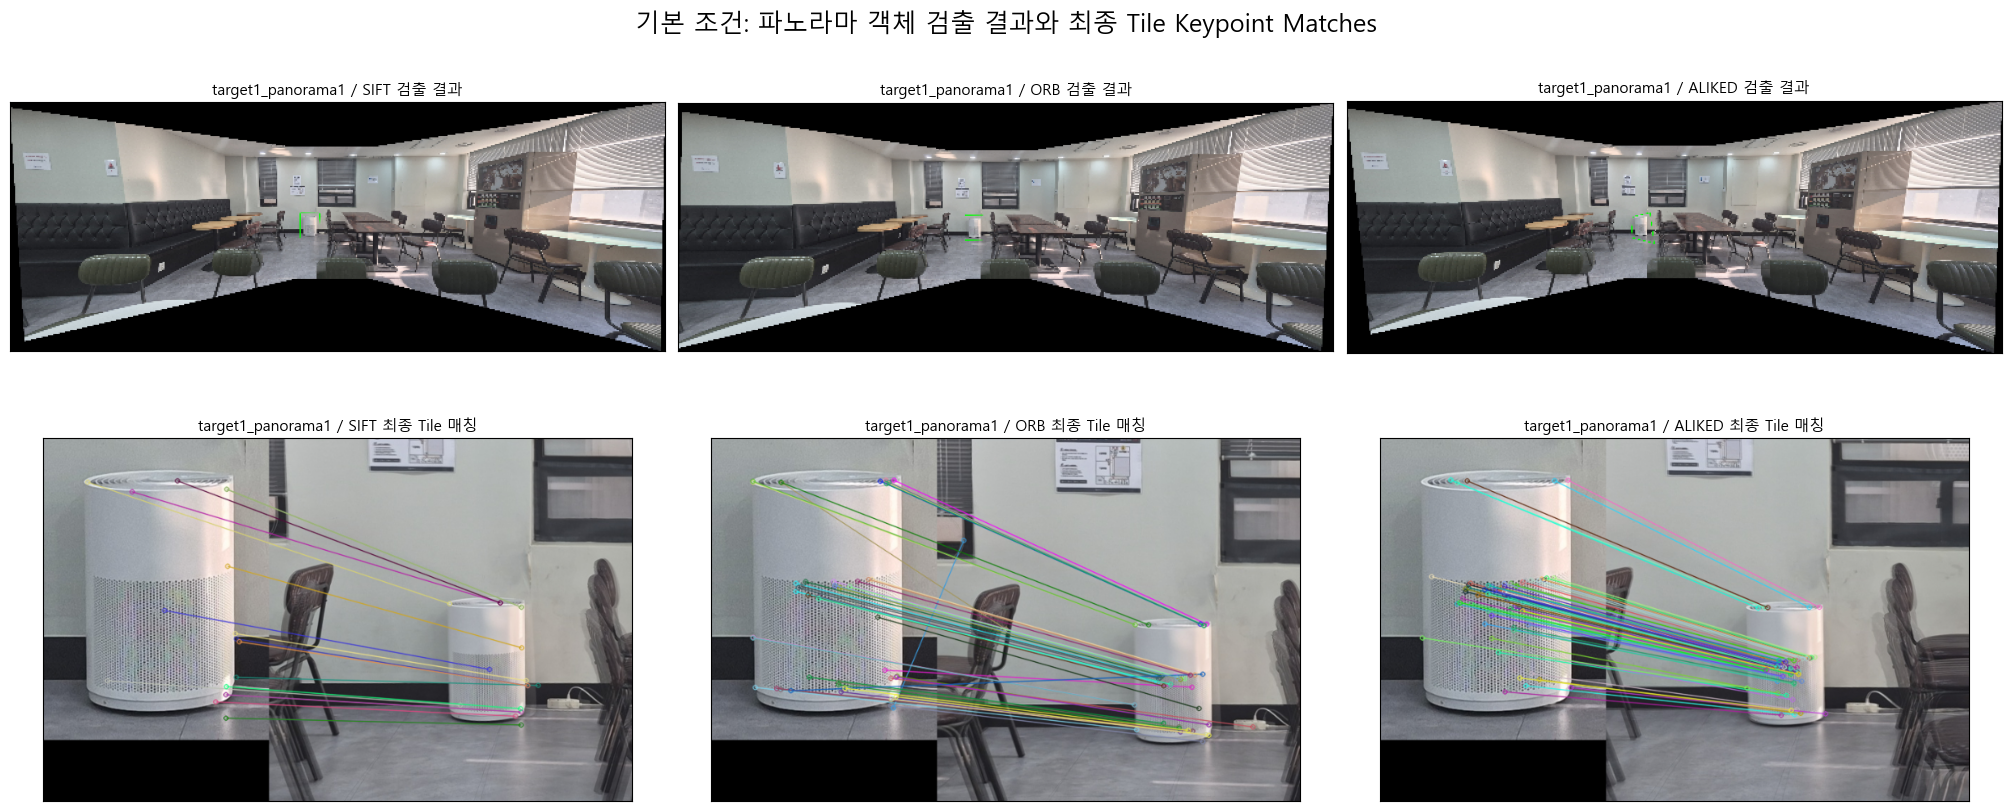

In [28]:
# ==========================================
# 기본 조건 검출 결과 및 최종 Tile 매칭 시각화
# - 위: Global Polygon이 표시된 최종 검출 결과
# - 아래: 같은 방법의 최종 Fine Tile Keypoint Matches
# ==========================================
VISUAL_CONDITION = 'baseline'

fig, axes = plt.subplots(
    2 * len(TEST_CASES),
    len(METHODS),
    figsize=(20, 8 * len(TEST_CASES)),
    constrained_layout=True,
)

for row, (case_name, _, _) in enumerate(TEST_CASES):
    for column, method in enumerate(METHODS):
        case_dir = RESULT_ROOT / case_name / VISUAL_CONDITION

        result_axis = axes[2 * row, column]
        result_axis.imshow(
            read_image_for_display(case_dir / (method + '_result.png'))
        )
        result_axis.set_title(case_name + ' / ' + method + ' 검출 결과', fontsize=11)

        match_axis = axes[2 * row + 1, column]
        match_path = case_dir / (method + '_keypoint_matches.png')
        if match_path.is_file():
            match_axis.imshow(read_image_for_display(match_path, max_width=700))
        else:
            match_axis.text(
                0.5, 0.5,
                '최종 Fine 후보 또는 매칭 이미지가 없습니다.',
                ha='center', va='center', wrap=True,
            )
        match_axis.set_title(case_name + ' / ' + method + ' 최종 Tile 매칭', fontsize=11)

        for axis in (result_axis, match_axis):
            axis.set_xticks([])
            axis.set_yticks([])

fig.suptitle('기본 조건: 파노라마 객체 검출 결과와 최종 Tile Keypoint Matches', fontsize=18)
plt.show()

## 10. 결론 작성 기준

5개 세트의 실험이 완료되면 `method_condition_summary.csv`를 기준으로 다음 내용을 정리합니다.

1. **검출 안정성**: `success_rate`가 가장 높은 방법과 취약한 변형 조건을 비교합니다.
2. **처리 속도**: `mean_elapsed`를 비교해 실시간성 또는 처리 비용 관점에서 해석합니다.
3. **매칭 신뢰도**: `mean_inlier_ratio`와 최종 타일 매칭 이미지를 함께 확인해 오검출 가능성을 검토합니다.
4. **종합 선택**: 정확도·속도·변형 강건성의 균형을 바탕으로 프로젝트 목적에 적합한 방법을 제안합니다.

각 세트가 추가되면 노트북을 위에서부터 다시 실행해 표·그래프·시각화 결과를 갱신합니다.